This is just an exploratory data analysis of the combined texas oil data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn 

In [41]:
df_cycle = pd.read_parquet("../../data/raw/texas/cleaned_data/texas_total_prod.parquet")
df_cycle.info()

<class 'pandas.DataFrame'>
RangeIndex: 19086019 entries, 0 to 19086018
Data columns (total 10 columns):
 #   Column               Dtype         
---  ------               -----         
 0   oil_gas_code         category      
 1   district_no          str           
 2   lease_no             str           
 3   field_no             str           
 4   lease_oil_prod_vol   int64         
 5   lease_csgd_prod_vol  float64       
 6   lease_csgd_tot_disp  int64         
 7   operator_no          str           
 8   operator_name        str           
 9   date                 datetime64[us]
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 2.1 GB


In [42]:
df_cycle.head(17)

,oil_gas_code,district_no,lease_no,field_no,lease_oil_prod_vol,lease_csgd_prod_vol,lease_csgd_tot_disp,operator_no,operator_name,date
0,O,03,24870,32688470,115,NaN,0,386310,HILCORP ENERGY COMPANY,2026-01-01
1,O,03,24870,32688470,349,NaN,0,386310,HILCORP ENERGY COMPANY,2026-02-01
2,O,03,24870,32688470,203,NaN,0,386310,HILCORP ENERGY COMPANY,2026-03-01
3,O,04,01097,36108001,278,NaN,0,386310,HILCORP ENERGY COMPANY,2026-01-01
4,O,04,01097,36108001,391,NaN,0,386310,HILCORP ENERGY COMPANY,2026-02-01
5,O,04,01097,36108001,426,NaN,0,386310,HILCORP ENERGY COMPANY,2026-03-01
6,O,01,01772,95888001,88,NaN,0,223502,DORCHESTER OPERATING COMPANY LLC,2026-01-01
7,O,01,01772,95888001,42,NaN,0,223502,DORCHESTER OPERATING COMPANY LLC,2026-02-01
8,O,01,01772,95888001,2,NaN,0,223502,DORCHESTER OPERATING COMPANY LLC,2026-03-01
9,O,01,01776,95888001,467,NaN,0,223502,DORCHESTER OPERATING COMPANY LLC,2026-01-01


In [43]:
df_cycle.columns = df_cycle.columns.str.lower()
df_cycle.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'field_no',
       'lease_oil_prod_vol', 'lease_csgd_prod_vol', 'lease_csgd_tot_disp',
       'operator_no', 'operator_name', 'date'],
      dtype='str')

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/matplotlib/image.py:183: UserWarning: Data with more than 2**24 rows cannot be accurately displayed. Downsampling to less than 2**24 rows before displaying. To remove this warning, manually downsample your data.
  warnings.warn(msg.format(n='2**24 rows'))


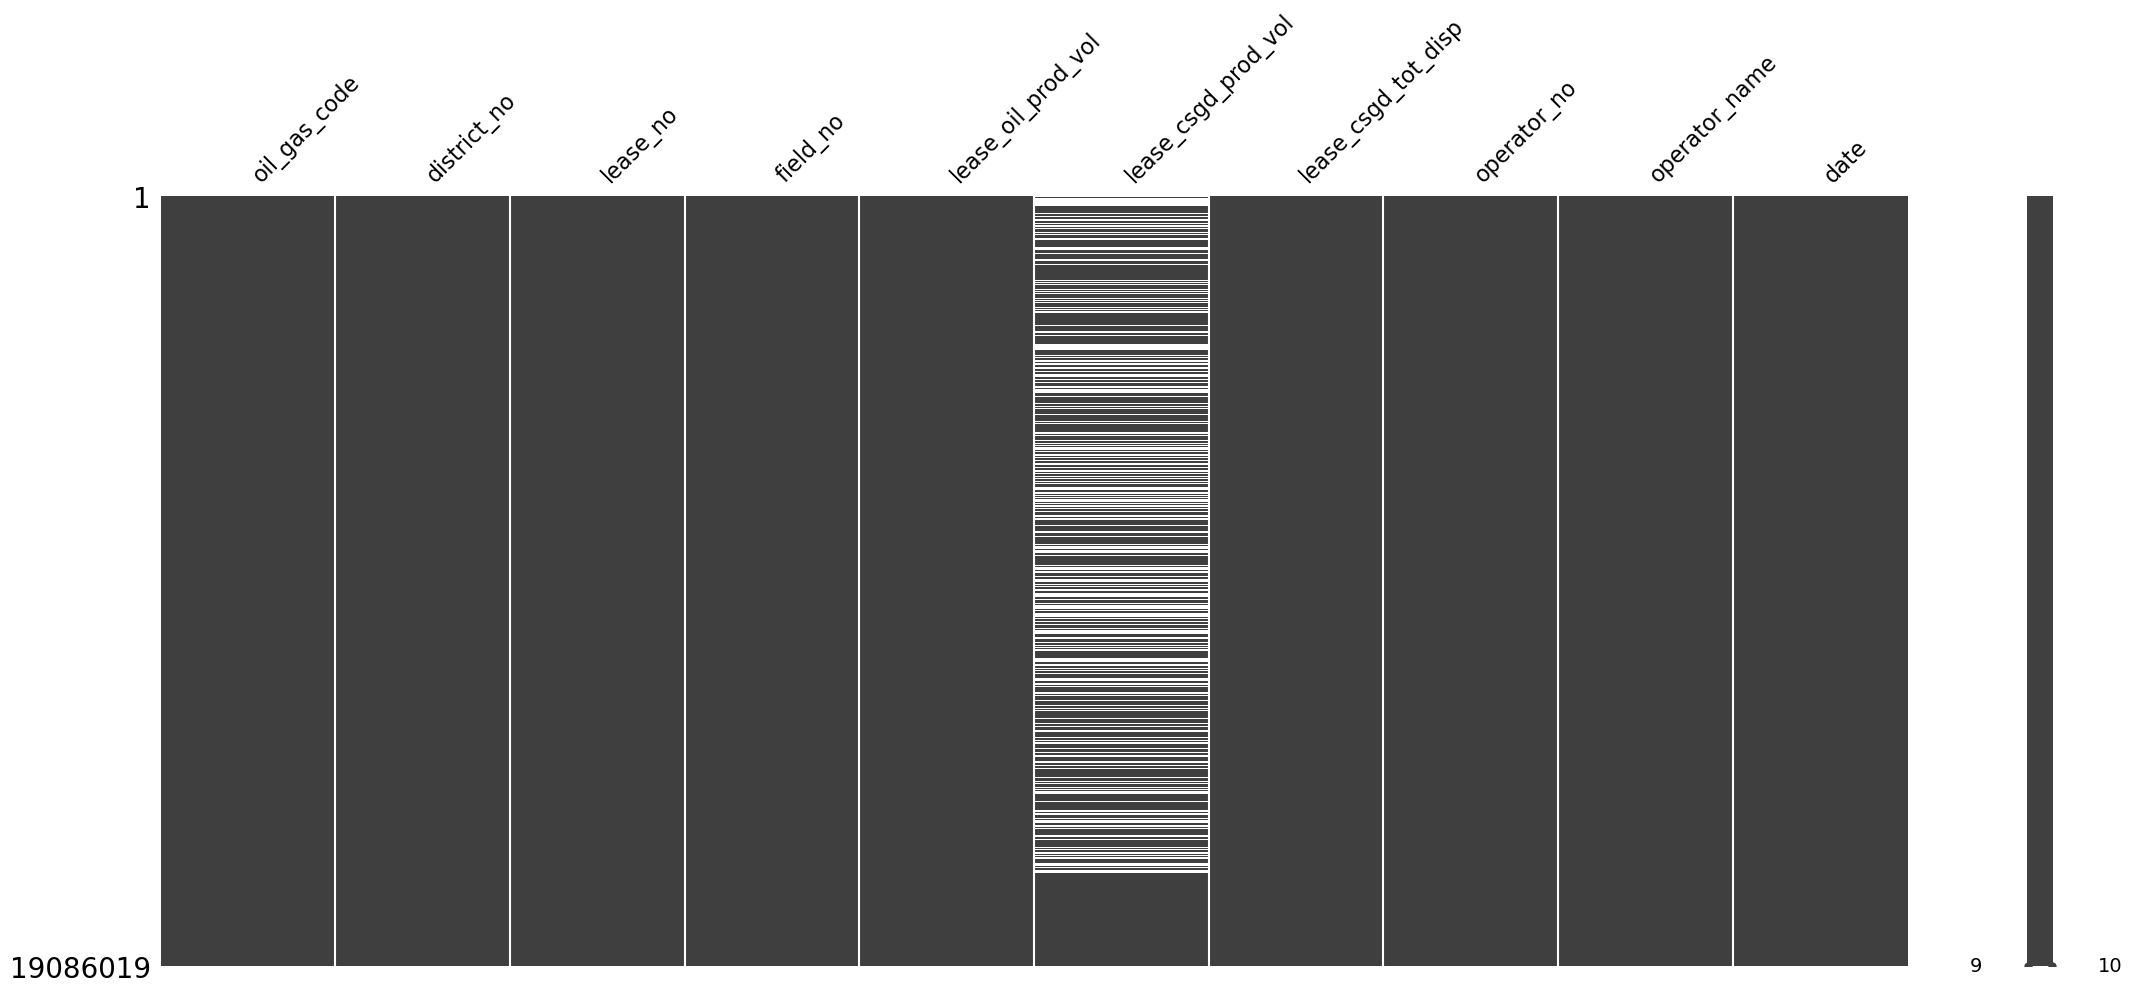

In [44]:
msn.matrix(df_cycle)
plt.show()

In [45]:
df_cycle.info()

<class 'pandas.DataFrame'>
RangeIndex: 19086019 entries, 0 to 19086018
Data columns (total 10 columns):
 #   Column               Dtype         
---  ------               -----         
 0   oil_gas_code         category      
 1   district_no          str           
 2   lease_no             str           
 3   field_no             str           
 4   lease_oil_prod_vol   int64         
 5   lease_csgd_prod_vol  float64       
 6   lease_csgd_tot_disp  int64         
 7   operator_no          str           
 8   operator_name        str           
 9   date                 datetime64[us]
dtypes: category(1), datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 2.1 GB


In [7]:
df_cycle.tail(30)

,oil_gas_code,district_no,lease_no,cycle_year_month,field_no,lease_oil_prod_vol,lease_csgd_prod_vol,lease_csgd_tot_disp,prod_date
31875610,O,09,10555,199307,02718400,22.0,164.0,164,1993-07-01
31875611,O,09,10555,199308,02718400,3.0,39.0,39,1993-08-01
31875612,O,09,10555,199309,02718400,1.0,215.0,215,1993-09-01
31875613,O,09,10555,199310,02718400,1.0,155.0,155,1993-10-01
31875614,O,09,10555,199311,02718400,1.0,157.0,157,1993-11-01
31875615,O,09,10555,199312,02718400,1.0,149.0,149,1993-12-01
31875616,O,11,66587,199301,82710664,NaN,NaN,0,1993-01-01
31875617,O,11,66587,199302,82710664,NaN,1.0,1,1993-02-01
31875618,O,11,66587,199303,82710664,NaN,NaN,0,1993-03-01
31875619,O,11,66587,199304,82710664,NaN,NaN,0,1993-04-01


In [47]:
date_group = df_cycle.groupby(['date'])
tot_vol = date_group.lease_oil_prod_vol.sum()
total_csgd_gas = date_group.lease_csgd_prod_vol.sum()
disp_csgd_gas = date_group.lease_csgd_tot_disp.sum()

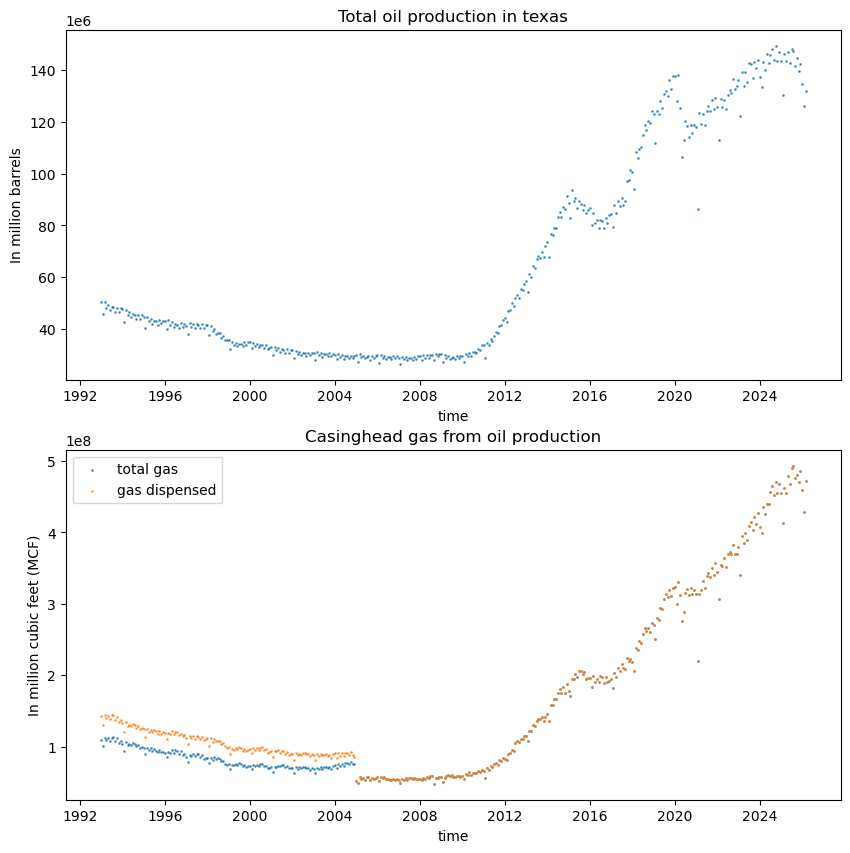

In [48]:
fig,ax = plt.subplots(2,1 , figsize = (10,10))

ax[0].scatter(tot_vol.index,tot_vol, alpha = 0.7, s = 0.9)
ax[0].ticklabel_format(style='sci', axis='y', scilimits=(6, 6))
ax[0].set_xlabel('time')
ax[0].set_ylabel('In million barrels')
ax[0].set_title('Total oil production in texas')

ax[1].scatter(total_csgd_gas.index,total_csgd_gas, alpha = 0.7, s = 0.9, label = 'total gas')
ax[1].scatter(disp_csgd_gas.index,disp_csgd_gas, alpha = 0.7, s = 0.9, label = 'gas dispensed')
ax[0].ticklabel_format(style='sci', axis='y', scilimits=(6, 6))
ax[1].set_xlabel('time')
ax[1].set_ylabel('In million cubic feet (MCF)')
ax[1].set_title('Casinghead gas from oil production')
ax[1].legend()


plt.show()

In [49]:
df_disp  = pd.read_parquet("../../data/raw/texas/cleaned_data/texas_prod_disp.parquet")
df_disp.info()

<class 'pandas.DataFrame'>
RangeIndex: 16761949 entries, 0 to 16761948
Data columns (total 29 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   oil_gas_code                  category      
 1   district_no                   str           
 2   lease_no                      str           
 3   field_no                      str           
 4   operator_no                   str           
 5   operator_name                 str           
 6   oil_pipeline_bbl              int64         
 7   oil_truck_bbl                 int64         
 8   oil_tankcar_bbl               int64         
 9   oil_tank_cleaning_bbl         int64         
 10  oil_circulating_bbl           int64         
 11  oil_lost_stolen_bbl           int64         
 12  oil_bsw_repressure_bbl        int64         
 13  oil_legacy_bbl                int64         
 14  oil_skimmed_bbl               int64         
 15  oil_scrubber_bbl              int64      

In [50]:
df_disp.columns = df_disp.columns.str.lower()
df_disp.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'field_no', 'operator_no',
       'operator_name', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'date'],
      dtype='str')

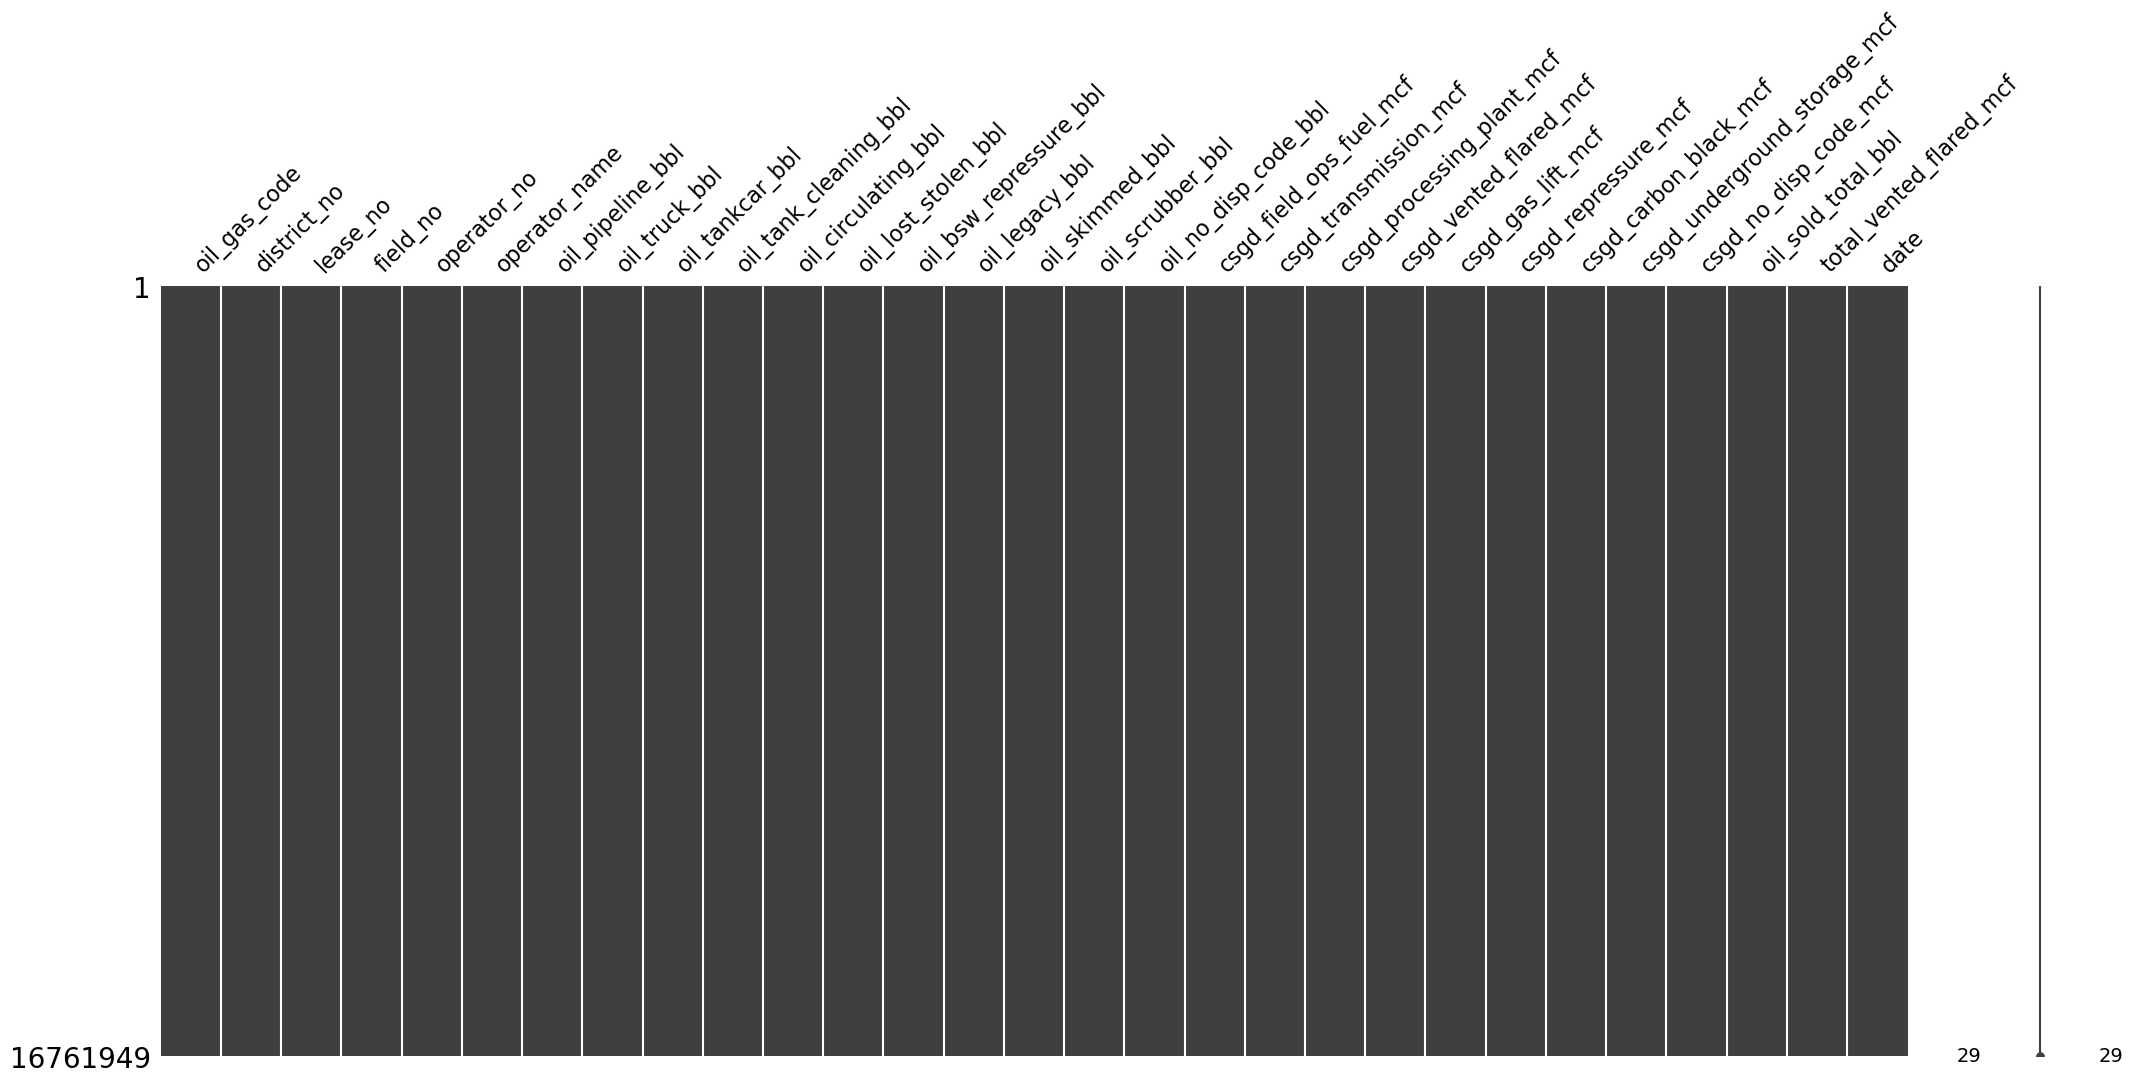

In [51]:
msn.matrix(df_disp)
plt.show()

In [52]:
disp_group = df_disp.groupby(['date']).sum(numeric_only = True)
disp_group.columns

Index(['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf'],
      dtype='str')

In [53]:
disp_group.index

DatetimeIndex(['1993-01-01', '1993-02-01', '1993-03-01', '1993-04-01',
               '1993-05-01', '1993-06-01', '1993-07-01', '1993-08-01',
               '1993-09-01', '1993-10-01',
               ...
               '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01',
               '2025-10-01', '2025-11-01', '2025-12-01', '2026-01-01',
               '2026-02-01', '2026-03-01'],
              dtype='datetime64[us]', name='date', length=399, freq=None)

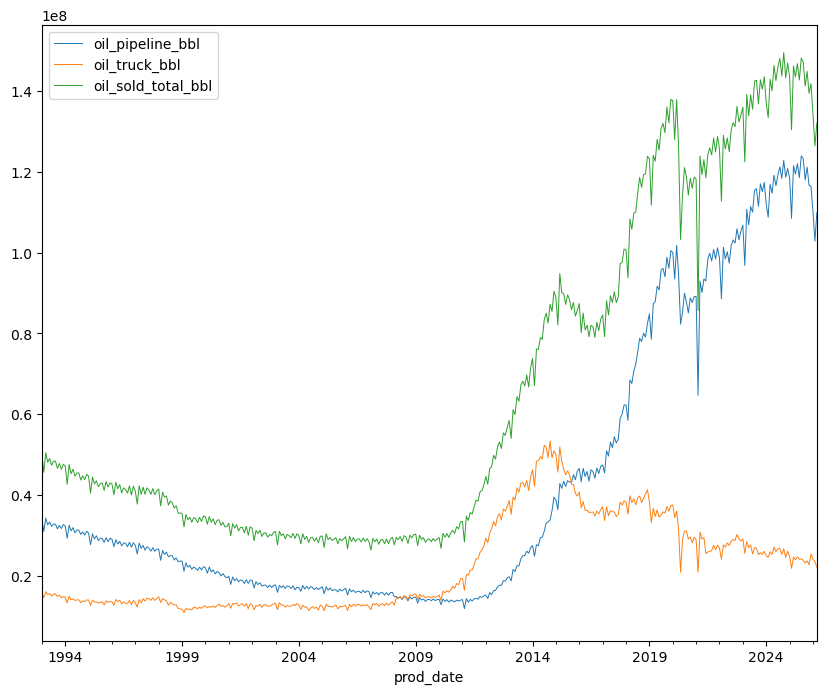

In [16]:
main_oil_columns = ['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_sold_total_bbl']
disp_group[main_oil_columns].plot(linewidth = 0.7, figsize = (10,8))
plt.show()

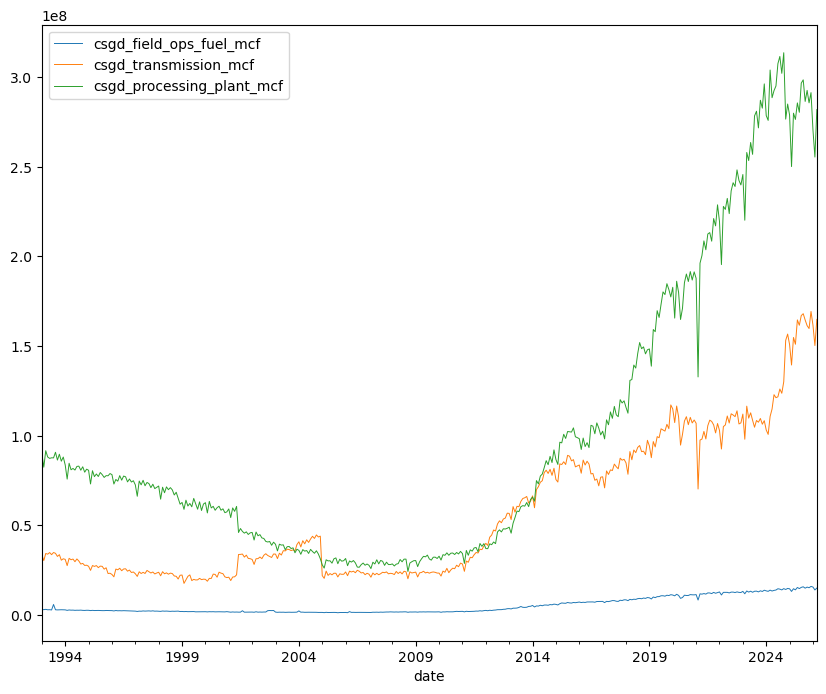

In [54]:
main_gas_columns = ['csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf']
disp_group[main_gas_columns].plot(linewidth = 0.7, figsize = (10,8))
plt.show()

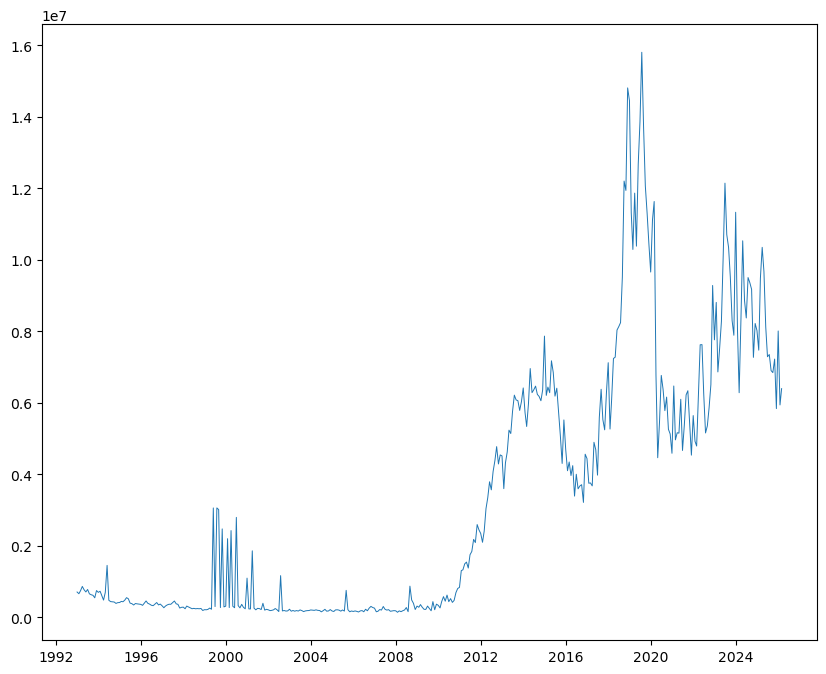

In [56]:
fig,axis = plt.subplots(figsize= (10,8))
axis.plot(disp_group.index, disp_group.csgd_vented_flared_mcf, linewidth = 0.7)
plt.show()

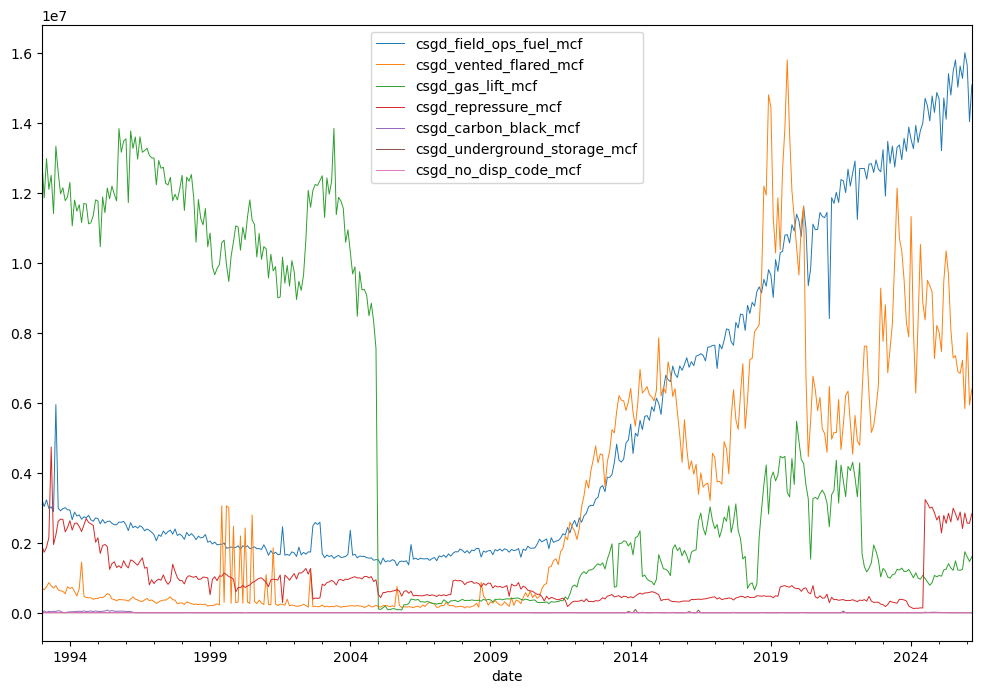

In [57]:
minor_gas_columns = ['csgd_field_ops_fuel_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf']
disp_group[minor_gas_columns].plot(linewidth = 0.7, figsize = (12,8))
plt.show()

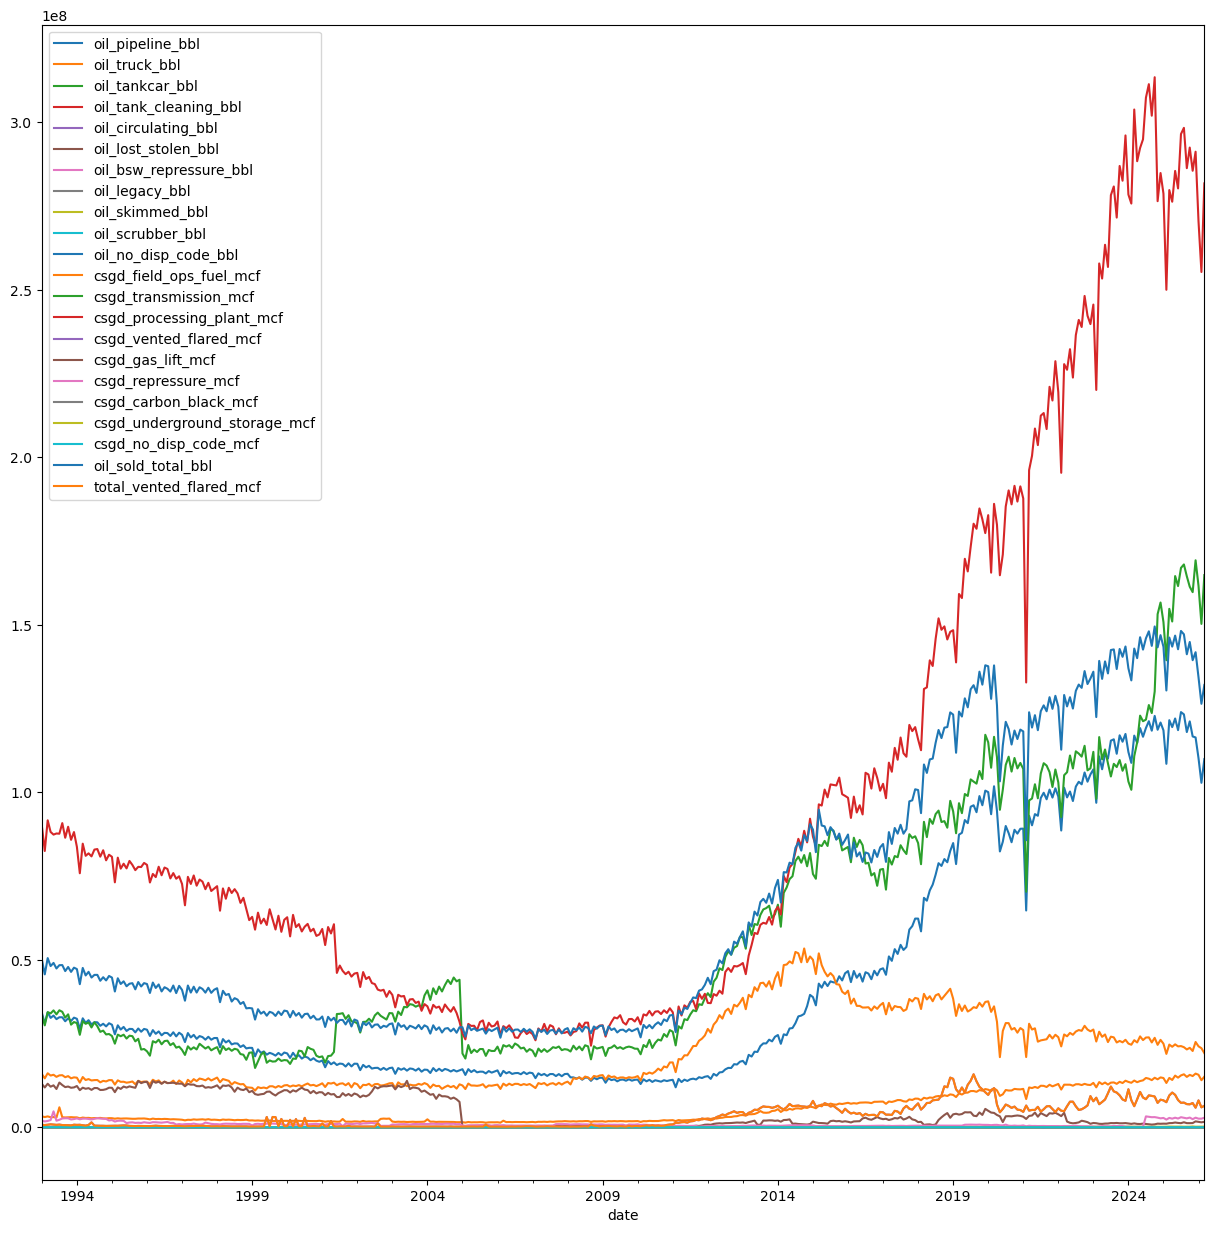

In [58]:
disp_group.plot(figsize=(15,15))
plt.show()

In [59]:
import os

# Update this to wherever you downloaded the file
FILE_PATH = "/Users/sabare/Desktop/Projects/summer26-permian-flaring/data/raw/texas"

# List all files in the download folder to find the exact filename
for f in os.listdir(FILE_PATH):
    print(f)

Wells
cleaned_data
daf804.txt
.DS_Store
digital-map-information-user-guide.pdf
coordinates
texas_pdq.zip
pdq_lease_output
pdq-dump-user-manual.pdf


In [60]:
# Peek at the first 5 lines to see the format
df_well = pd.read_parquet("../../data/raw/texas/cleaned_data/well_api_lease.parquet")
df_well.info()

<class 'pandas.DataFrame'>
RangeIndex: 587614 entries, 0 to 587613
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   OIL_GAS_CODE            587614 non-null  category
 1   DISTRICT_NO             587614 non-null  str     
 2   LEASE_NO                587614 non-null  str     
 3   WELL_NO                 587614 non-null  str     
 4   API_COUNTY_CODE         587614 non-null  str     
 5   API_UNIQUE_NO           587614 non-null  str     
 6   COUNTY_NAME             587614 non-null  str     
 7   WELLBORE_LOCATION_CODE  587614 non-null  str     
 8   API_NO                  587614 non-null  str     
dtypes: category(1), str(8)
memory usage: 54.8 MB


In [61]:
df_well.head(20)

,OIL_GAS_CODE,DISTRICT_NO,LEASE_NO,WELL_NO,API_COUNTY_CODE,API_UNIQUE_NO,COUNTY_NAME,WELLBORE_LOCATION_CODE,API_NO
0,O,08,00277,17,049,31721,BROWN,L,04931721
1,O,08,00277,18,049,32950,BROWN,L,04932950
2,O,08,00287,1,049,05559,BROWN,L,04905559
3,O,08,00291,1,049,05919,BROWN,L,04905919
4,O,08,00291,2,049,80560,BROWN,L,04980560
5,O,08,00291,3,049,30486,BROWN,L,04930486
6,O,08,00291,4,049,04704,BROWN,L,04904704
7,O,08,00291,7,049,35384,BROWN,L,04935384
8,O,08,00292,1,049,05369,BROWN,L,04905369
9,O,08,00292,2,049,80563,BROWN,L,04980563


In [62]:
df_cycle.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'field_no',
       'lease_oil_prod_vol', 'lease_csgd_prod_vol', 'lease_csgd_tot_disp',
       'operator_no', 'operator_name', 'date'],
      dtype='str')

In [63]:
df_well.columns

Index(['OIL_GAS_CODE', 'DISTRICT_NO', 'LEASE_NO', 'WELL_NO', 'API_COUNTY_CODE',
       'API_UNIQUE_NO', 'COUNTY_NAME', 'WELLBORE_LOCATION_CODE', 'API_NO'],
      dtype='str')

In [64]:
df_disp.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'field_no', 'operator_no',
       'operator_name', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'date'],
      dtype='str')

In [65]:
df_disp[['oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl']].describe().loc[['mean', 'max']]

,oil_pipeline_bbl,oil_truck_bbl,oil_tankcar_bbl,oil_tank_cleaning_bbl,oil_circulating_bbl,oil_lost_stolen_bbl,oil_bsw_repressure_bbl,oil_legacy_bbl,oil_skimmed_bbl,oil_scrubber_bbl,oil_no_disp_code_bbl
mean,1.022473e+03,536.491821,0.542346,0.031705,0.052028,0.057225,0.04057,0.297895,1.710951,0.213161,0.002125
max,1.812841e+06,449901.000000,26213.000000,3722.000000,2628.000000,58831.000000,3746.00000,69683.000000,64062.000000,45539.000000,1871.000000


In [66]:
df_disp[['csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf']].describe().loc[['mean','max']]

,csgd_field_ops_fuel_mcf,csgd_transmission_mcf,csgd_processing_plant_mcf,csgd_vented_flared_mcf,csgd_gas_lift_mcf,csgd_repressure_mcf,csgd_carbon_black_mcf,csgd_underground_storage_mcf,csgd_no_disp_code_mcf
mean,1.243073e+02,1.347039e+03,2.355378e+03,7.617680e+01,1.199368e+02,2.122196e+01,0.088915,0.032343,0.001193
max,2.993379e+06,1.183358e+07,7.620023e+06,2.798949e+06,1.658438e+06,3.086485e+06,10473.000000,93208.000000,7801.000000


In [67]:
maj_col = ['csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf']
int_col = ['csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf']
min_col = ['csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf']

<Axes: xlabel='date'>

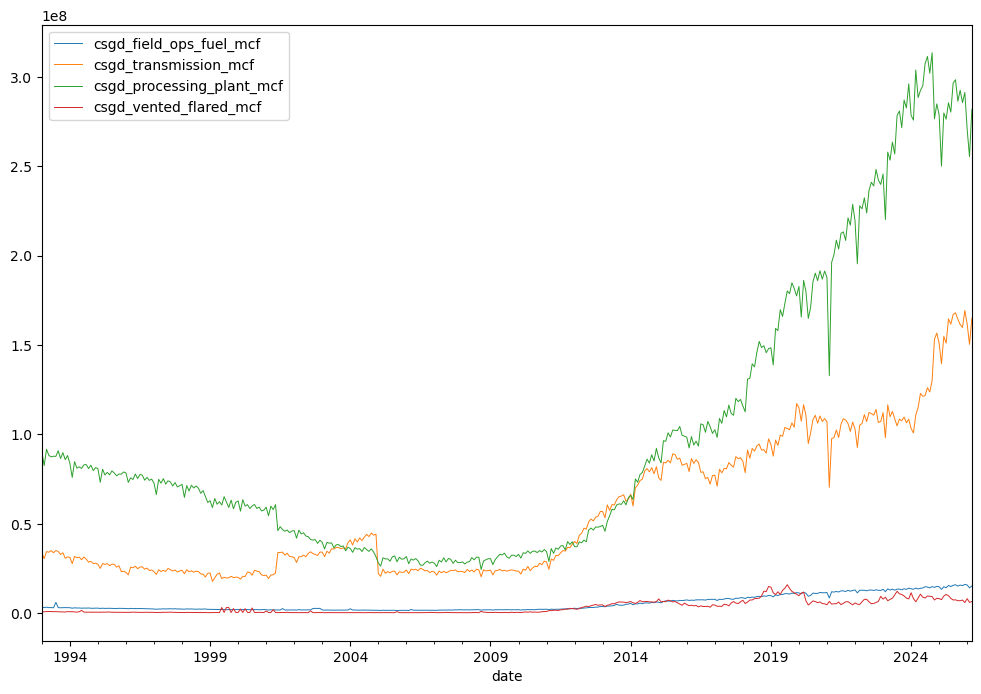

In [68]:
disp_group[maj_col].plot(linewidth = 0.7, figsize = (12,8))

<Axes: xlabel='date'>

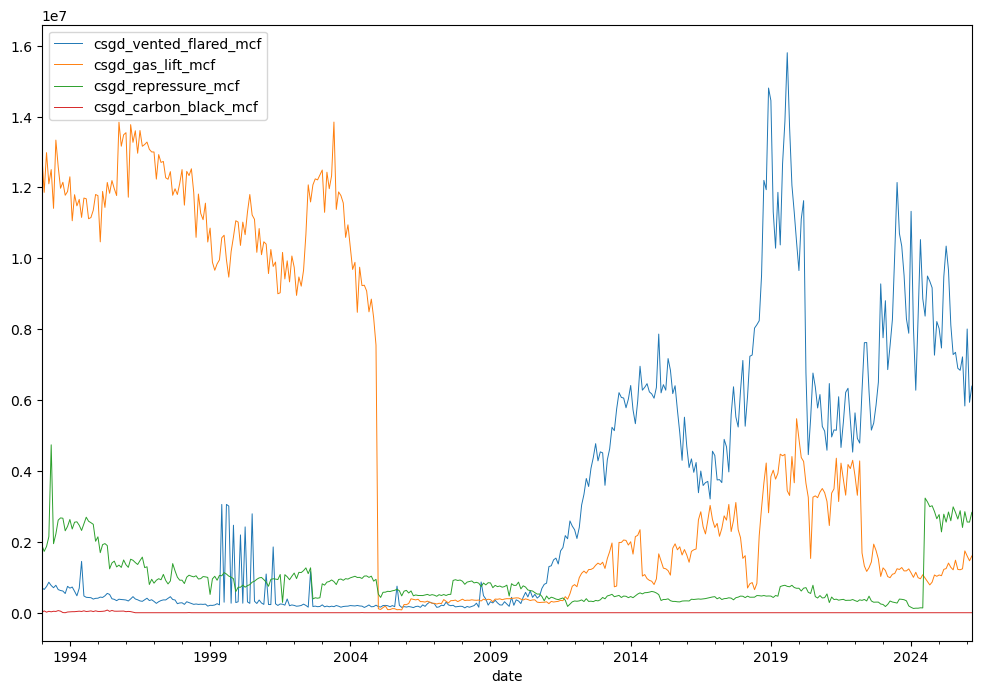

In [69]:
disp_group[int_col].plot(linewidth = 0.7, figsize = (12,8))

<Axes: xlabel='date'>

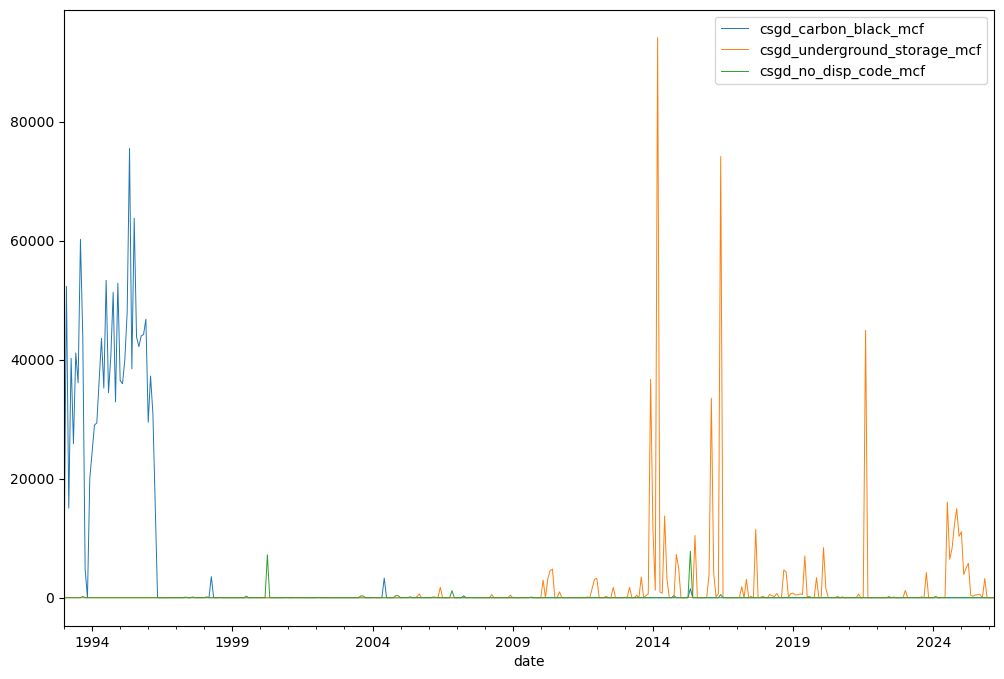

In [70]:
disp_group[min_col].plot(linewidth = 0.7, figsize = (12,8))